In [ ]:
# Instala a API de transcrição
!pip install youtube-transcript-api -q

from google.colab import drive
import os

# Monta o Google Drive
drive.mount('/content/drive')

# Define o diretório raiz para salvar as transcrições no Drive
# Você pode alterar o nome da pasta se preferir
BASE_DIR = '/content/drive/MyDrive/NER/Transcricoes'
os.makedirs(BASE_DIR, exist_ok=True)

print(f"\n[OK] Diretório de destino configurado: {BASE_DIR}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 485.2/485.2 kB 8.8 MB/s eta 0:00:00
Mounted at /content/drive

[OK] Diretório de destino configurado: /content/drive/MyDrive/NER/Transcricoes


In [ ]:
from youtube_transcript_api import YouTubeTranscriptApi
from youtube_transcript_api.formatters import TextFormatter
import re
import json
import os

def extract_video_id(url):
    """Extrai o ID do vídeo a partir de diferentes formatos de URL do YouTube."""
    regex = r"(?:v=|\/)([0-9A-Za-z_-]{11}).*"
    match = re.search(regex, url)
    return match.group(1) if match else None

def get_transcript(video_id, languages=['pt', 'en']):
    """
    Obtém a transcrição do vídeo utilizando a nova sintaxe da API.
    A lista 'languages' define a ordem de prioridade dos idiomas.
    """
    try:
        api = YouTubeTranscriptApi()
        transcript_obj = api.fetch(video_id, languages=languages)
        return transcript_obj.to_raw_data()
    except Exception as e:
        print(f"  [ERRO] Não foi possível obter transcrição para o ID {video_id}. Detalhes: {e}")
        return None

def save_transcript(video_id, transcript, base_dir):
    """Salva a transcrição nos formatos JSON e TXT."""
    if not transcript:
        return False

    # 1. Salva como JSON (preserva os timestamps, útil para os metadados do seu grafo NER depois)
    json_path = os.path.join(base_dir, f"{video_id}.json")
    with open(json_path, 'w', encoding='utf-8') as f:
        json.dump(transcript, f, ensure_ascii=False, indent=4)

    # 2. Salva como TXT puro (texto contínuo para processamento NLP)
    # Correção: Extrai diretamente a chave 'text' de cada dicionário da lista
    text_formatted = "\n".join([item['text'] for item in transcript])

    text_path = os.path.join(base_dir, f"{video_id}.txt")
    with open(text_path, 'w', encoding='utf-8') as f:
        f.write(text_formatted)

    print(f"  [SUCESSO] Arquivos {video_id}.json e {video_id}.txt salvos no Drive.")
    return True

In [ ]:
# Lista de URLs dos vídeos do YouTube
video_urls = [
    "https://youtu.be/7xTGNNLPyMI?si=Vpw7fdd65-fGPnLF"
]

print(f"Iniciando processamento de {len(video_urls)} vídeo(s)...\n")

for url in video_urls:
    video_id = extract_video_id(url)

    if not video_id:
        print(f"[AVISO] URL inválida ignorada: {url}")
        continue

    # Regra de cache: verifica se o processamento já foi feito antes
    expected_txt_file = os.path.join(BASE_DIR, f"{video_id}.txt")
    if os.path.exists(expected_txt_file):
        print(f"[-] Vídeo ID {video_id} já processado anteriormente. Pulando...")
        continue

    print(f"[+] Processando vídeo ID: {video_id}...")
    transcript_data = get_transcript(video_id, languages=['pt', 'pt-BR', 'en'])

    if transcript_data:
        save_transcript(video_id, transcript_data, BASE_DIR)

print("\nProcessamento finalizado!")

Iniciando processamento de 1 vídeo(s)...

[+] Processando vídeo ID: 7xTGNNLPyMI...
  [SUCESSO] Arquivos 7xTGNNLPyMI.json e 7xTGNNLPyMI.txt salvos no Drive.

Processamento finalizado!


In [ ]:
import sys
!{sys.executable} -m spacy download en_core_web_sm

Carregando o texto e inicializando o spaCy (isso pode levar alguns segundos)...

ESTATÍSTICAS BÁSICAS DO VÍDEO
Total de Palavras: 48175
Total de Frases: 712

ANÁLISE DE ENTIDADES NOMEADAS (NER)
Distribuição dos Tipos de Entidades:
 - CARDINAL: 382 ocorrências
 - ORG: 116 ocorrências
 - PERSON: 105 ocorrências
 - ORDINAL: 72 ocorrências
 - DATE: 61 ocorrências
 - GPE: 41 ocorrências
 - MONEY: 30 ocorrências
 - NORP: 27 ocorrências
 - PRODUCT: 13 ocorrências
 - TIME: 12 ocorrências
 - PERCENT: 11 ocorrências
 - LANGUAGE: 11 ocorrências
 - WORK_OF_ART: 10 ocorrências
 - QUANTITY: 7 ocorrências
 - LOC: 6 ocorrências
 - FAC: 4 ocorrências

Top 10 Entidades Mais Citadas (Pessoas, Organizações, Locais, Produtos):
 - RL: 34x
 - AI: 30x
 - GPT: 25x
 - gpt2: 9x
 - Wikipedia: 8x
 - Network: 7x
 - Solutions: 7x
 - Google: 6x
 - Orson: 6x
 - Transformer: 5x

TÓPICOS E CONCEITOS PRINCIPAIS
Top 10 Substantivos/Termos Chave:
 - model: 552x
 - example: 171x
 - token: 158x
 - kind: 132x
 - answer: 120x


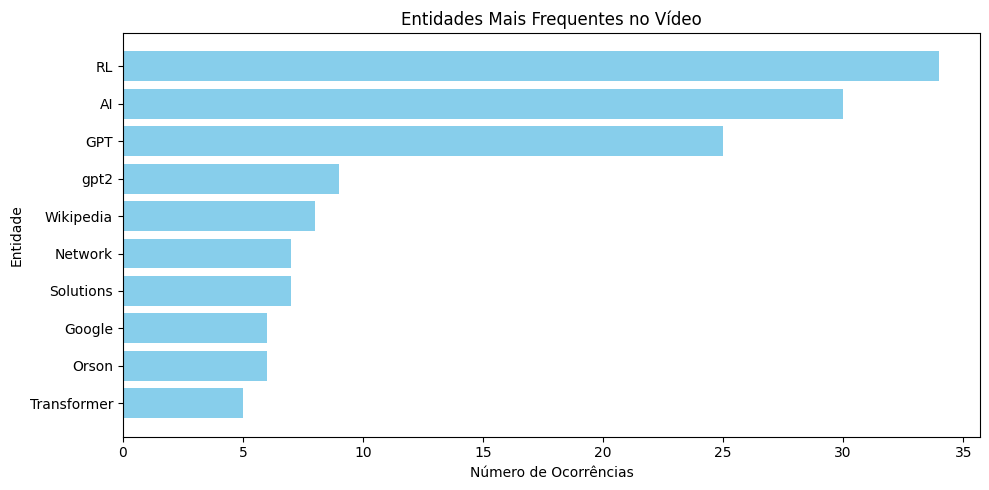

In [ ]:
import spacy
from collections import Counter
import matplotlib.pyplot as plt
import os

VIDEO_ID = "7xTGNNLPyMI"
TEXT_FILE_PATH = f"/content/drive/MyDrive/NER/Transcricoes/{VIDEO_ID}.txt"

# Verifica se o arquivo existe
if not os.path.exists(TEXT_FILE_PATH):
    print(f"[ERRO] Arquivo não encontrado: {TEXT_FILE_PATH}")
    print("Verifique se o ID está correto e se o passo de transcrição foi concluído.")
else:
    # 2. Carrega o texto e o modelo do spaCy
    print("Carregando o texto e inicializando o spaCy (isso pode levar alguns segundos)...")
    with open(TEXT_FILE_PATH, 'r', encoding='utf-8') as f:
        text = f.read()

    nlp = spacy.load("en_core_web_sm")
    doc = nlp(text)

    # 3. Extração de Estatísticas Básicas
    num_words = len([token for token in doc if not token.is_punct])
    num_sentences = len(list(doc.sents))
    print("\n" + "="*40)
    print("ESTATÍSTICAS BÁSICAS DO VÍDEO")
    print("="*40)
    print(f"Total de Palavras: {num_words}")
    print(f"Total de Frases: {num_sentences}")

    # 4. Extração de Entidades Nomeadas (NER)
    print("\n" + "="*40)
    print("ANÁLISE DE ENTIDADES NOMEADAS (NER)")
    print("="*40)

    # Conta a frequência de cada categoria de entidade (ex: ORG, PERSON, GPE)
    entity_labels = Counter([ent.label_ for ent in doc.ents])
    print("Distribuição dos Tipos de Entidades:")
    for label, count in entity_labels.most_common():
        print(f" - {label}: {count} ocorrências")

    # Extrai as entidades específicas mais citadas (filtrando Pessoas, Organizações e Locais)
    target_labels = ['PERSON', 'ORG', 'GPE', 'PRODUCT']
    top_entities = Counter([ent.text.strip() for ent in doc.ents if ent.label_ in target_labels])

    print("\nTop 10 Entidades Mais Citadas (Pessoas, Organizações, Locais, Produtos):")
    for ent, count in top_entities.most_common(10):
        print(f" - {ent}: {count}x")

    # 5. Extração de Conceitos (Substantivos mais comuns, ignorando Stop Words)
    # Isso ajuda a entender o "assunto" do vídeo além das entidades com nome próprio
    keywords = Counter([
        token.lemma_.lower() for token in doc
        if token.pos_ in ['NOUN', 'PROPN'] and not token.is_stop and token.is_alpha
    ])

    print("\n" + "="*40)
    print("TÓPICOS E CONCEITOS PRINCIPAIS")
    print("="*40)
    print("Top 10 Substantivos/Termos Chave:")
    for word, count in keywords.most_common(10):
        print(f" - {word}: {count}x")

    # 6. Visualização Gráfica das Entidades
    # Plota as entidades mais comuns para facilitar a visualização
    top_n = 10
    if top_entities:
        labels, values = zip(*top_entities.most_common(top_n))

        plt.figure(figsize=(10, 5))
        plt.barh(labels[::-1], values[::-1], color='skyblue')
        plt.title('Entidades Mais Frequentes no Vídeo')
        plt.xlabel('Número de Ocorrências')
        plt.ylabel('Entidade')
        plt.tight_layout()
        plt.show()
    else:
        print("\n[AVISO] Nenhuma entidade alvo foi encontrada para gerar o gráfico.")

Processando frases e mapeando conexões...
Grafo gerado com 23 nós e 29 arestas.


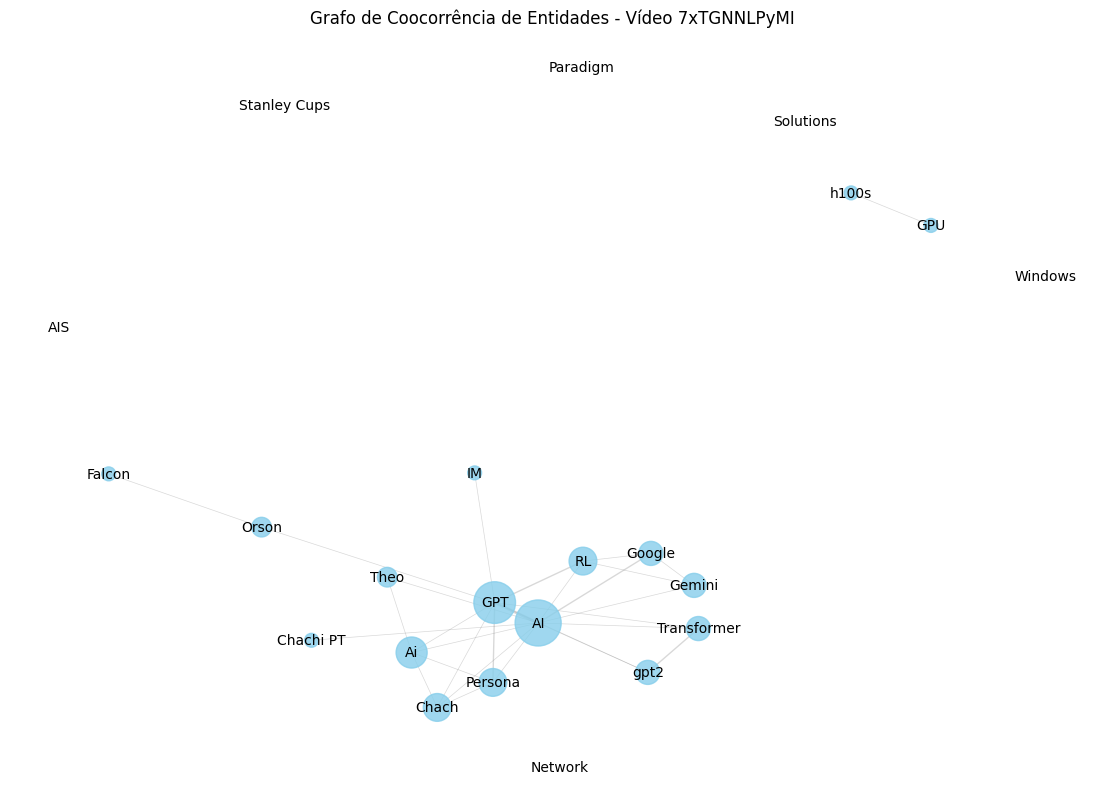

In [ ]:
import networkx as nx
from itertools import combinations

# Configurações iniciais
VIDEO_ID = "7xTGNNLPyMI"
TEXT_FILE_PATH = f"/content/drive/MyDrive/NER/Transcricoes/{VIDEO_ID}.txt"
MIN_FREQUENCY = 2  # Filtra entidades que aparecem pouco para reduzir ruído
TARGET_LABELS = ['PERSON', 'ORG', 'GPE', 'PRODUCT', 'AI_TERM'] # Categorias de interesse

def generate_graph():
    if not os.path.exists(TEXT_FILE_PATH):
        print("Arquivo não encontrado!")
        return

    with open(TEXT_FILE_PATH, 'r', encoding='utf-8') as f:
        text = f.read()

    nlp = spacy.load("en_core_web_sm")
    doc = nlp(text)

    # 1. Construção do Grafo
    G = nx.Graph()
    entity_counts = {}

    print("Processando frases e mapeando conexões...")
    for sent in doc.sents:
        # Extrai entidades únicas na frase atual que estão nas categorias alvo
        ents_in_sentence = list(set([
            ent.text.strip().replace("\n", " ")
            for ent in sent.ents
            if ent.label_ in TARGET_LABELS and len(ent.text.strip()) > 1
        ]))

        # Atualiza contagem global para filtro posterior
        for ent in ents_in_sentence:
            entity_counts[ent] = entity_counts.get(ent, 0) + 1

        # Cria conexões (arestas) entre todas as entidades da mesma frase
        if len(ents_in_sentence) > 1:
            for pair in combinations(ents_in_sentence, 2):
                if G.has_edge(*pair):
                    G[pair[0]][pair[1]]['weight'] += 1
                else:
                    G.add_edge(pair[0], pair[1], weight=1)

    # 2. Filtragem por frequência (Limpeza do Grafo)
    nodes_to_remove = [node for node, count in entity_counts.items() if count < MIN_FREQUENCY]
    G.remove_nodes_from(nodes_to_remove)

    print(f"Grafo gerado com {G.number_of_nodes()} nós e {G.number_of_edges()} arestas.")

    # 3. Visualização
    plt.figure(figsize=(14, 10))

    # Layout dinâmico (Spring Layout)
    pos = nx.spring_layout(G, k=0.5, iterations=50)

    # Define tamanho dos nós baseado na importância (grau de conexão)
    node_sizes = [G.degree(node) * 100 for node in G.nodes()]

    # Desenha o grafo
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='skyblue', alpha=0.8)
    nx.draw_networkx_edges(G, pos, width=[G[u][v]['weight'] * 0.5 for u, v in G.edges()], alpha=0.3, edge_color='gray')
    nx.draw_networkx_labels(G, pos, font_size=10, font_family='sans-serif')

    plt.title(f"Grafo de Coocorrência de Entidades - Vídeo {VIDEO_ID}")
    plt.axis('off')
    plt.show()

generate_graph()